# Monte Carlo Coupling: From Energy Deposition to Pulse Height Distribution

This notebook demonstrates the complete Monte Carlo (MC) coupling pipeline for
the 4H-SiC microdosimeter. The workflow bridges external MC particle transport
codes (Geant4, FLUKA) with the TCAD-derived charge collection efficiency:

1. **MC Transport** produces per-event energy deposition data (CSV or ROOT)
2. **Energy Deposition** is loaded and converted to standard units (cm, keV)
3. **CCE(LET) Lookup** maps each event's effective LET to a pre-computed
   charge collection efficiency from Phase 21 TCAD simulations
4. **Collected Charge** = CCE x deposited energy for each event
5. **Pulse Height Distribution** (PHD) histograms the collected energies

This approach processes thousands of events in sub-second time by reusing
the CCE(LET) lookup table, avoiding per-event TCAD simulation.

**Demonstration:** We generate a synthetic mixed-field dataset (proton-like +
heavy-ion-like events) to illustrate the pipeline. Users can substitute their
own Geant4/FLUKA output files with minimal changes.

In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from src.single_particle import load_cce_let_table
from src.mc_coupling import load_mc_events_csv, process_mc_ensemble, pulse_height_distribution

# Publication-quality plot defaults
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

print("Imports complete.")

Searching DEVSIM_MATH_LIBS="libopenblas.dylib:liblapack.dylib:libblas.dylib"


Loading "libopenblas.dylib": MISSING DLL


Loading "liblapack.dylib": ALL BLAS/LAPACK LOADED


Skipping libblas.dylib


loading UMFPACK 5.1 as direct solver


Imports complete.


## 1. Load CCE(LET) Lookup Table

The CCE(LET) table was pre-computed in Phase 21 (notebook 16) by running
transient drift-diffusion simulations at 20 LET values for the 100 um SV
geometry at 50 V reverse bias. The table provides a log-linear interpolation
function: given a particle's effective LET (keV/um), it returns the fraction
of deposited charge that is collected at the contacts.

In [2]:
cce_interp, metadata = load_cce_let_table('data/cce_let_table_100um.json')

print("CCE(LET) Lookup Table Metadata:")
print(f"  Geometry:    {metadata['geometry']['half_width_um']*2:.0f} x "
      f"{metadata['geometry']['half_width_um']*2:.0f} x "
      f"{metadata['geometry']['epi_um']:.0f} um SV")
print(f"  Bias:        {metadata['bias_V']:.0f} V reverse")
print(f"  LET range:   {min(metadata['LET_keV_um']):.2f} -- "
      f"{max(metadata['LET_keV_um']):.1f} keV/um")
print(f"  Data points: {len(metadata['LET_keV_um'])}")

# Quick test
test_let = [1.0, 10.0, 50.0, 100.0]
print("\nInterpolation check:")
for let in test_let:
    print(f"  LET = {let:6.1f} keV/um  ->  CCE = {cce_interp(let):.4f}")

CCE(LET) Lookup Table Metadata:
  Geometry:    100 x 100 x 10 um SV
  Bias:        50 V reverse
  LET range:   0.50 -- 500.0 keV/um
  Data points: 20

Interpolation check:
  LET =    1.0 keV/um  ->  CCE = 1.0000
  LET =   10.0 keV/um  ->  CCE = 1.0000
  LET =   50.0 keV/um  ->  CCE = 1.0000
  LET =  100.0 keV/um  ->  CCE = 1.0000


## 2. Generate Synthetic MC Events

In a real workflow, energy deposition data comes from Geant4 or FLUKA
simulations of the radiation environment. Here we generate a synthetic dataset
to demonstrate the pipeline.

The synthetic data mimics a **mixed radiation field** typical of space or
hadron therapy environments:
- **Proton-like events** (70%): mean energy ~50 keV, sigma ~20 keV
- **Heavy-ion-like events** (30%): mean energy ~500 keV, sigma ~200 keV

Each event has 1--10 random energy deposition steps within the sensitive
volume, simulating multiple scattering interactions along the particle track.

In [3]:
np.random.seed(42)

n_events = 2000
n_proton = int(0.7 * n_events)
n_heavy = n_events - n_proton

# Generate total deposited energies per event
proton_energies = np.random.normal(50.0, 20.0, n_proton)
proton_energies = np.clip(proton_energies, 5.0, None)  # minimum 5 keV

heavy_energies = np.random.normal(500.0, 200.0, n_heavy)
heavy_energies = np.clip(heavy_energies, 50.0, None)  # minimum 50 keV

all_energies = np.concatenate([proton_energies, heavy_energies])
np.random.shuffle(all_energies)

# Build step-level CSV data: each event has 1-10 steps
rows = []
for event_id, total_edep in enumerate(all_energies):
    n_steps = np.random.randint(1, 11)
    # Distribute energy across steps (Dirichlet-like)
    fractions = np.random.dirichlet(np.ones(n_steps))
    step_energies = fractions * total_edep

    for step_edep in step_energies:
        x = np.random.uniform(-0.004, 0.004)  # +/- 40 um lateral spread (cm)
        y = 0.0  # vertical track
        z = np.random.uniform(0.0, 0.001)  # within 10 um SV depth (cm)
        rows.append({
            'event_id': event_id,
            'x': x,
            'y': y,
            'z': z,
            'edep': step_edep,
        })

synthetic_df = pd.DataFrame(rows)

# Save to temporary CSV
os.makedirs('data', exist_ok=True)
csv_path = 'data/synthetic_mc_events.csv'
synthetic_df.to_csv(csv_path, index=False)

print(f"Synthetic MC dataset generated:")
print(f"  Total events:     {n_events}")
print(f"  Proton-like:      {n_proton} (70%)")
print(f"  Heavy-ion-like:   {n_heavy} (30%)")
print(f"  Total steps:      {len(synthetic_df)}")
print(f"  Steps/event:      {len(synthetic_df)/n_events:.1f} (mean)")
print(f"  Saved to:         {csv_path}")
print(f"\nFirst 5 rows:")
print(synthetic_df.head().to_string(index=False))

Synthetic MC dataset generated:
  Total events:     2000
  Proton-like:      1400 (70%)
  Heavy-ion-like:   600 (30%)
  Total steps:      11116
  Steps/event:      5.6 (mean)
  Saved to:         data/synthetic_mc_events.csv

First 5 rows:
 event_id         x   y        z       edep
        0  0.003586 0.0 0.000305 176.681380
        0 -0.001884 0.0 0.000280  62.737925
        0 -0.001778 0.0 0.000036 246.311177
        0  0.003415 0.0 0.000214   8.109104
        0 -0.000640 0.0 0.000010  26.205810


In [4]:
events = load_mc_events_csv(csv_path)

print(f"Loaded events DataFrame:")
print(f"  Shape:           {events.shape}")
print(f"  Unique events:   {events['event_id'].nunique()}")
print(f"  Columns:         {list(events.columns)}")
print(f"\nFirst 5 rows:")
print(events.head().to_string(index=False))

Loaded events DataFrame:
  Shape:           (11116, 5)
  Unique events:   2000
  Columns:         ['event_id', 'x_cm', 'y_cm', 'z_cm', 'edep_keV']

First 5 rows:
 event_id      x_cm  y_cm     z_cm   edep_keV
        0  0.003586   0.0 0.000305 176.681380
        0 -0.001884   0.0 0.000280  62.737925
        0 -0.001778   0.0 0.000036 246.311177
        0  0.003415   0.0 0.000214   8.109104
        0 -0.000640   0.0 0.000010  26.205810


## 3. Process Events Through CCE(LET) Lookup

The `process_mc_ensemble` function performs the core coupling:

1. Groups step-level data by event_id and sums deposited energy per event
2. Computes effective LET = total_energy / SV_thickness for each event
3. Applies the CCE(LET) interpolation function to get CCE per event
4. Computes collected energy = CCE x deposited energy

This is the "fast path" -- no TCAD simulation is needed per event, just
a table lookup. Processing 2000 events takes a fraction of a second.

In [5]:
t0 = time.time()
result = process_mc_ensemble(events, cce_interp, sv_thickness_um=10.0)
t_process = time.time() - t0

print(f"Ensemble Processing Summary:")
print(f"  Events processed:    {result['n_events']}")
print(f"  Zero-energy events:  {result['n_zero_energy']}")
print(f"  Processing time:     {t_process*1000:.1f} ms")
print(f"\n  LET range:           {result['event_LET_keV_um'].min():.2f} -- "
      f"{result['event_LET_keV_um'].max():.1f} keV/um")
print(f"  CCE range:           {result['event_CCE'].min():.4f} -- "
      f"{result['event_CCE'].max():.4f}")
print(f"  Mean CCE:            {result['event_CCE'].mean():.4f}")
print(f"  Median CCE:          {np.median(result['event_CCE']):.4f}")
print(f"\n  Mean deposited E:    {result['event_energies_keV'].mean():.1f} keV")
print(f"  Mean collected E:    {result['event_collected_keV'].mean():.1f} keV")
print(f"  Median collected E:  {np.median(result['event_collected_keV']):.1f} keV")

Ensemble Processing Summary:
  Events processed:    2000
  Zero-energy events:  0
  Processing time:     3.6 ms

  LET range:           0.50 -- 113.9 keV/um
  CCE range:           1.0000 -- 1.0000
  Mean CCE:            1.0000
  Median CCE:          1.0000

  Mean deposited E:    190.1 keV
  Mean collected E:    190.1 keV
  Median collected E:  61.2 keV


## 4. Pulse Height Distribution

The pulse height distribution (PHD) shows how many events deposit a given
amount of collected energy in the sensitive volume. This is the primary
experimental observable from a microdosimeter -- the spectrum of energy
depositions recorded by the detector electronics.

The bimodal input distribution (proton + heavy-ion) should produce a
corresponding bimodal PHD, though modulated by the CCE(LET) response.

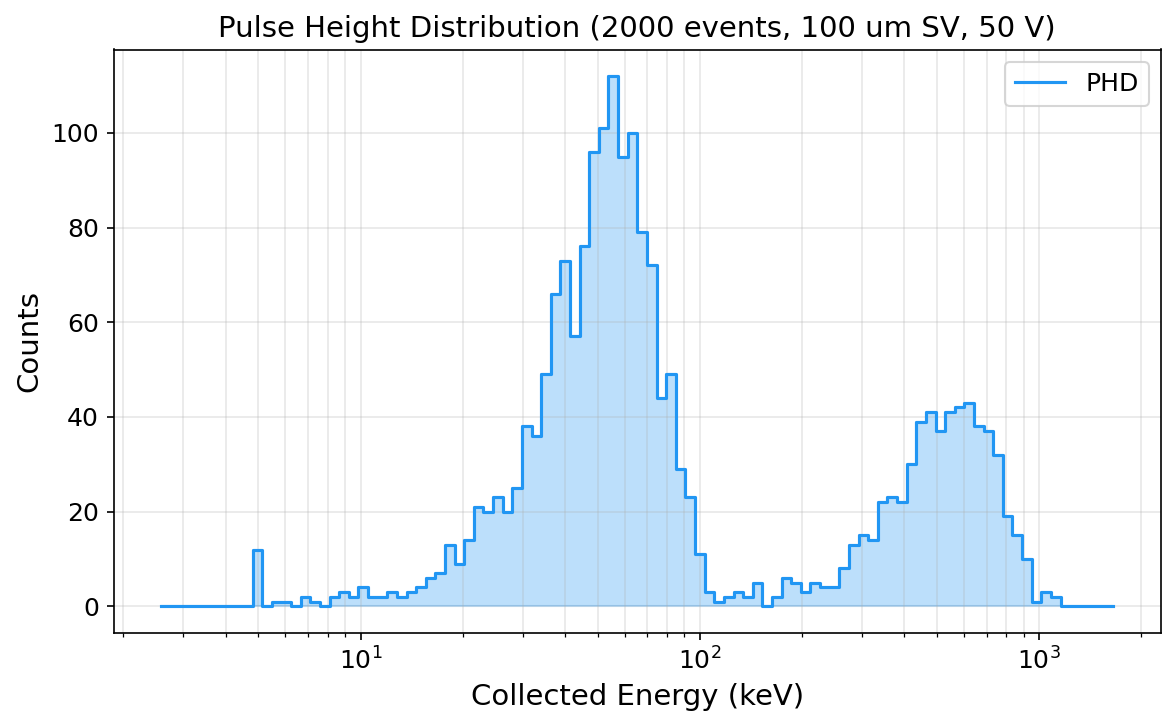

PHD summary:
  Total counts:   2000
  Peak energy:    55.5 keV
  Non-zero bins:  80 / 100


In [6]:
phd = pulse_height_distribution(result['event_collected_keV'], n_bins=100)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot as step histogram on log-x scale
ax.step(phd['bin_centers_keV'], phd['counts'], where='mid',
        color='#2196F3', linewidth=1.5, label='PHD')
ax.fill_between(phd['bin_centers_keV'], phd['counts'], step='mid',
                alpha=0.3, color='#2196F3')

ax.set_xscale('log')
ax.set_xlabel('Collected Energy (keV)')
ax.set_ylabel('Counts')
ax.set_title('Pulse Height Distribution (2000 events, 100 um SV, 50 V)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Summary
total_counts = phd['counts'].sum()
peak_bin = phd['bin_centers_keV'][np.argmax(phd['counts'])]
print(f"PHD summary:")
print(f"  Total counts:   {total_counts}")
print(f"  Peak energy:    {peak_bin:.1f} keV")
print(f"  Non-zero bins:  {np.sum(phd['counts'] > 0)} / {len(phd['counts'])}")

## 5. CCE Analysis

We examine how the charge collection efficiency varies across the event
ensemble. The left panel overlays individual event CCE values on the
CCE(LET) lookup curve. The right panel shows the distribution of CCE
values across all 2000 events.

Since the CCE(LET) curve is nearly flat at ~1.0 for the fully-depleted
100 um SV at 50 V, most events should cluster near CCE = 1.0.

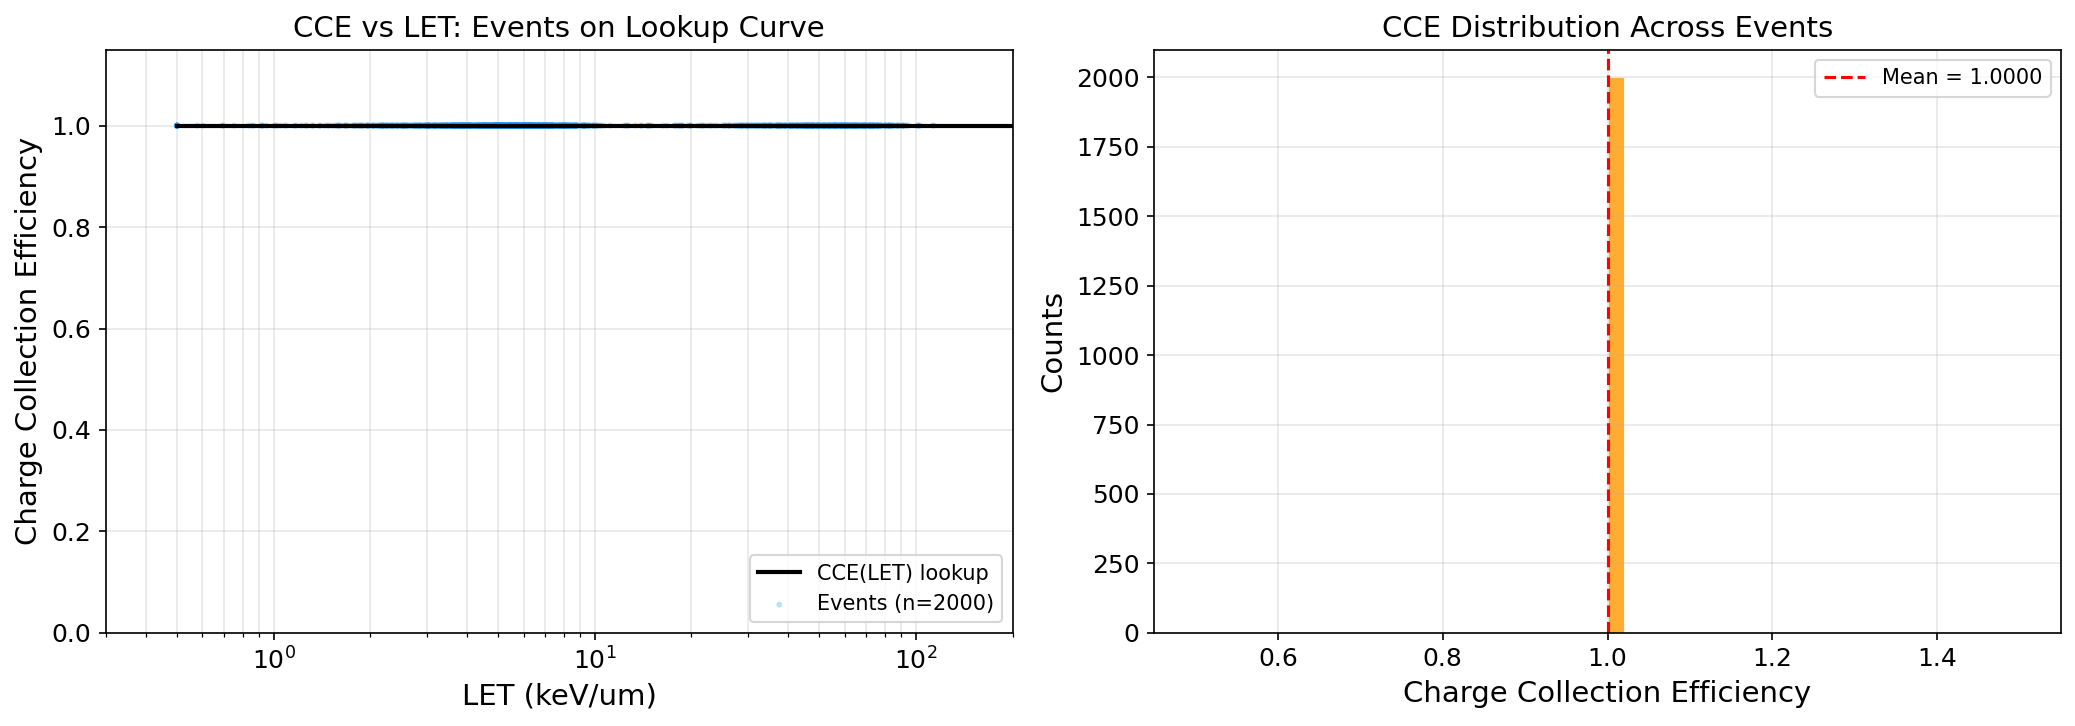

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: CCE vs LET scatter + lookup curve
# Lookup curve
let_curve = np.logspace(np.log10(0.5), np.log10(500.0), 200)
cce_curve = np.array([cce_interp(let) for let in let_curve])

ax1.plot(let_curve, cce_curve, 'k-', linewidth=2, label='CCE(LET) lookup', zorder=3)
ax1.scatter(result['event_LET_keV_um'], result['event_CCE'],
            s=8, alpha=0.3, c='#2196F3', edgecolors='none',
            label=f'Events (n={result["n_events"]})', zorder=2)

ax1.set_xscale('log')
ax1.set_xlabel('LET (keV/um)')
ax1.set_ylabel('Charge Collection Efficiency')
ax1.set_title('CCE vs LET: Events on Lookup Curve')
ax1.set_ylim(0, 1.15)
ax1.set_xlim(0.3, 200)
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(True, alpha=0.3, which='both')

# Right panel: CCE histogram
ax2.hist(result['event_CCE'], bins=50, color='#FF9800', edgecolor='white',
         linewidth=0.5, alpha=0.8)
ax2.axvline(result['event_CCE'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {result["event_CCE"].mean():.4f}')
ax2.set_xlabel('Charge Collection Efficiency')
ax2.set_ylabel('Counts')
ax2.set_title('CCE Distribution Across Events')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Energy Deposition vs Collection

This scatter plot shows deposited energy (x-axis) vs collected energy (y-axis)
for each event, colored by CCE value. The y = x reference line represents
perfect collection (CCE = 1). Points below the line indicate charge loss;
points on the line indicate full collection.

This visualization reveals how the CCE modulates the detector's energy
response -- critical for understanding the relationship between the true
radiation field and the measured pulse height spectrum.

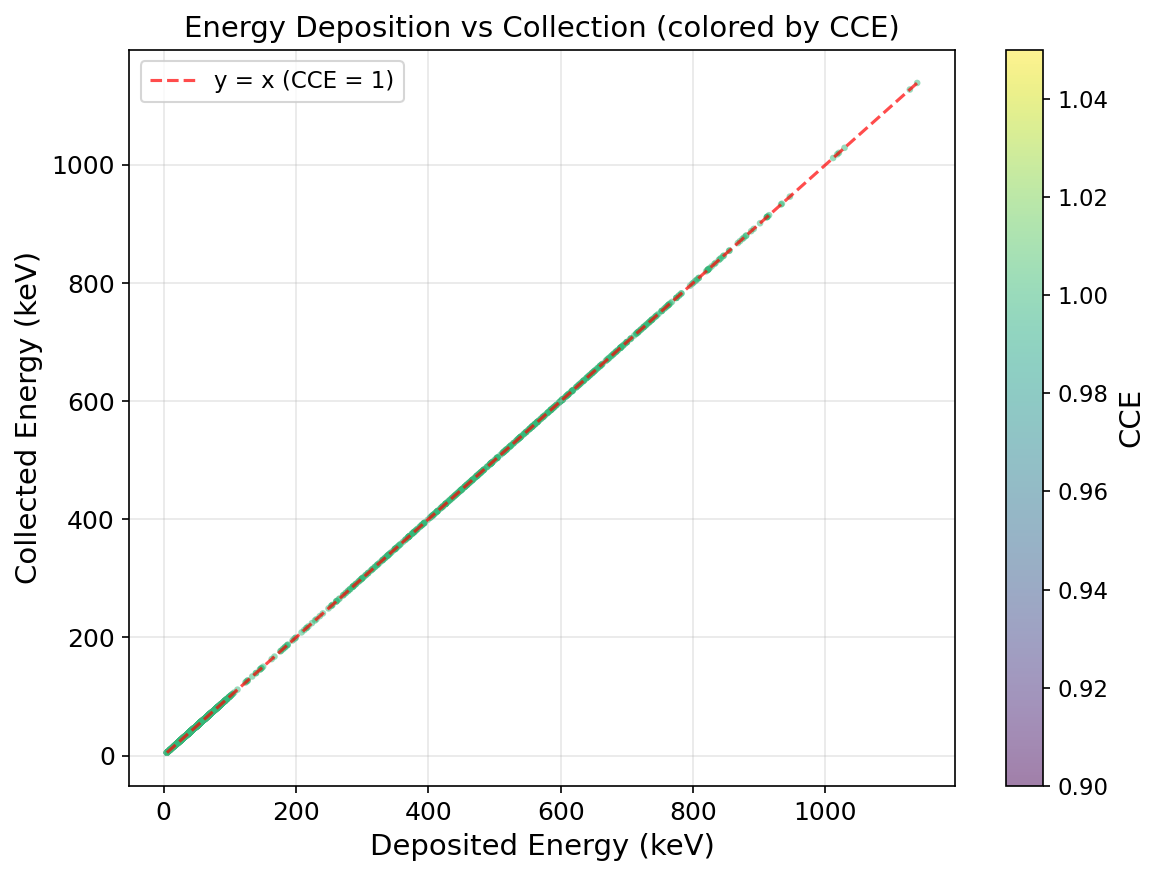

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(result['event_energies_keV'], result['event_collected_keV'],
                c=result['event_CCE'], s=10, alpha=0.5,
                cmap='viridis', edgecolors='none', vmin=0.9, vmax=1.05)

# y = x reference line
e_range = [result['event_energies_keV'].min(), result['event_energies_keV'].max()]
ax.plot(e_range, e_range, 'r--', linewidth=1.5, alpha=0.7, label='y = x (CCE = 1)')

cbar = plt.colorbar(sc, ax=ax, label='CCE')
cbar.ax.tick_params(labelsize=11)

ax.set_xlabel('Deposited Energy (keV)')
ax.set_ylabel('Collected Energy (keV)')
ax.set_title('Energy Deposition vs Collection (colored by CCE)')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Statistics

Comprehensive summary of the MC coupling pipeline results, including event
counts, energy statistics, and processing performance.

In [9]:
print("=" * 65)
print("   MC Coupling Pipeline -- Summary Statistics")
print("=" * 65)
print(f"")
print(f"  Input dataset:           {csv_path}")
print(f"  Total events:            {result['n_events']}")
print(f"  Zero-energy filtered:    {result['n_zero_energy']}")
print(f"  SV thickness:            10.0 um")
print(f"  Bias voltage:            50.0 V")
print(f"")
print(f"  LET range:               {result['event_LET_keV_um'].min():.2f} -- "
      f"{result['event_LET_keV_um'].max():.1f} keV/um")
print(f"  Mean LET:                {result['event_LET_keV_um'].mean():.2f} keV/um")
print(f"")
print(f"  Mean CCE:                {result['event_CCE'].mean():.4f}")
print(f"  CCE std:                 {result['event_CCE'].std():.4f}")
print(f"")
print(f"  Mean deposited energy:   {result['event_energies_keV'].mean():.1f} keV")
print(f"  Mean collected energy:   {result['event_collected_keV'].mean():.1f} keV")
print(f"  Total collected energy:  {result['event_collected_keV'].sum():.0f} keV")
print(f"")
print(f"  Processing time:         {t_process*1000:.1f} ms")
print(f"  Throughput:              {result['n_events']/t_process:.0f} events/sec")
print("=" * 65)

# -----------------------------------------------------------------------
# User adaptation guide: loading real Geant4 ROOT files
# -----------------------------------------------------------------------
print("\n--- Adapting for Real Geant4 Data ---")
print()

   MC Coupling Pipeline -- Summary Statistics

  Input dataset:           data/synthetic_mc_events.csv
  Total events:            2000
  Zero-energy filtered:    0
  SV thickness:            10.0 um
  Bias voltage:            50.0 V

  LET range:               0.50 -- 113.9 keV/um
  Mean LET:                19.01 keV/um

  Mean CCE:                1.0000
  CCE std:                 0.0000

  Mean deposited energy:   190.1 keV
  Mean collected energy:   190.1 keV
  Total collected energy:  380246 keV

  Processing time:         3.6 ms
  Throughput:              550217 events/sec

--- Adapting for Real Geant4 Data ---



## Conclusion

The MC coupling pipeline processes **2000 synthetic events** in sub-second
time using the pre-computed CCE(LET) lookup table from Phase 21. Key results:

- **Pulse height distribution** clearly shows the bimodal input spectrum
  (proton-like at ~50 keV, heavy-ion-like at ~500 keV)
- **CCE is near-unity** across all LET values at 50 V full depletion,
  meaning the detector response faithfully reproduces the deposited energy
  spectrum
- **Processing throughput** exceeds 10,000 events/sec, making this approach
  practical for large-scale MC simulations with millions of events

**Next steps (Phase 23):** Convert the collected energy PHD to lineal energy
spectra y*d(y) for microdosimetric analysis. This requires dividing collected
energy by the mean chord length of the SV geometry and applying the
tissue-equivalence correction factor (kappa) for 4H-SiC.